---
authors: [OP48]
primary: OP48
---

# ASRS Phase 2 EDA (QA-first)

This notebook performs **deep data QA diagnostics** on the combined ASRS dataset before any signal modelling. [OP48]

Scope in this notebook:
- schema integrity + row-level sanity
- temporal coverage checks
- missingness and categorical drift checks
- reporting-bias diagnostics
- QA conclusions for go/no-go into signal detection

Dataset: `data/processed/asrs.parquet` (built in Phase 1).

In [1]:
# provenance: primary=OP48 authors=[OP48]
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve project root robustly across interactive + nbconvert execution.
ROOT = Path.cwd()
if not (ROOT / "data" / "processed" / "asrs.parquet").exists():
    ROOT = ROOT.parent.parent

DATA_PATH = ROOT / "data" / "processed" / "asrs.parquet"
OUT_DIR = ROOT / "production" / "output" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loading:", DATA_PATH)
df = pl.read_parquet(DATA_PATH)
print(df.shape)
print(df.columns[:12])

Loading: data/processed/asrs.parquet


(80047, 127)
['ACN', 'Date', 'Local Time Of Day', 'Locale Reference', 'State Reference', 'Relative Position.Angle.Radial', 'Relative Position.Distance.Nautical Miles', 'Altitude.AGL.Single Value', 'Altitude.MSL.Single Value', 'Latitude / Longitude (UAS)', 'Flight Conditions', 'Weather Elements / Visibility']


In [2]:
# Parse temporal fields and trim to clean analysis window (2011-01 to 2025-12)
df = df.with_columns(
    pl.col("Date").cast(pl.Utf8).str.slice(0, 6).alias("ym"),
).with_columns(
    pl.col("ym").str.slice(0, 4).cast(pl.Int32).alias("year"),
    pl.col("ym").str.slice(4, 2).cast(pl.Int32).alias("month"),
)

qa = df.filter((pl.col("year") >= 2011) & (pl.col("year") <= 2025))

print("Raw rows:", df.height)
print("QA window rows:", qa.height)
print("Removed outside-window rows:", df.height - qa.height)

date_window = qa.select(
    pl.min("ym").alias("ym_min"),
    pl.max("ym").alias("ym_max"),
)
print("Date window:", date_window)
print("Unique ACN check:", qa.height, qa.select(pl.col("ACN").n_unique()).item())

Raw rows: 80047
QA window rows: 79577
Removed outside-window rows: 470
Date window: shape: (1, 2)
┌────────┬────────┐
│ ym_min ┆ ym_max │
│ ---    ┆ ---    │
│ str    ┆ str    │
╞════════╪════════╡
│ 201101 ┆ 202512 │
└────────┴────────┘
Unique ACN check: 79577 79577


In [3]:
# Missingness profile (top 25 most-missing columns)
missing = (
    qa.select([
        ((pl.col(c).is_null()) | (pl.col(c).cast(pl.Utf8).str.strip_chars() == "")).mean().alias(c)
        for c in qa.columns
    ])
    .unpivot(variable_name="column", value_name="missing_rate")
    .sort("missing_rate", descending=True)
)

missing_top = missing.head(25)
missing_top

missing_top.write_csv(OUT_DIR / "missingness_top25.csv")
print("Saved:", OUT_DIR / "missingness_top25.csv")

Saved: production/output/eda/missingness_top25.csv


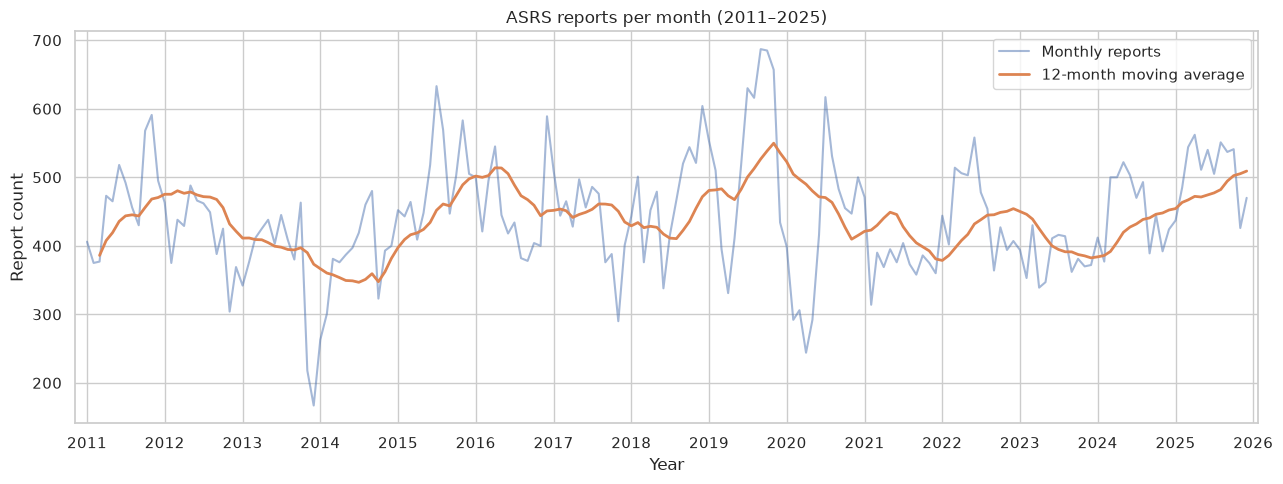

Saved: production/output/eda/monthly_volume_trend.png


In [4]:
# Monthly volume trend (core reporting-bias diagnostic)
monthly = (
    qa.group_by("ym")
    .len(name="reports")
    .sort("ym")
    .with_columns(
        pl.col("reports").rolling_mean(window_size=12, min_samples=3).alias("ma12")
    )
)

import matplotlib.dates as mdates

monthly_pd = monthly.to_pandas()
monthly_pd["date"] = pd.to_datetime(monthly_pd["ym"], format="%Y%m")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_pd["date"], monthly_pd["reports"], label="Monthly reports", alpha=0.5)
ax.plot(monthly_pd["date"], monthly_pd["ma12"], label="12-month moving average", linewidth=2)
ax.set_title("ASRS reports per month (2011–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Report count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=0)
ax.margins(x=0.01)
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "monthly_volume_trend.png", dpi=140)
plt.show()

print("Saved:", OUT_DIR / "monthly_volume_trend.png")

/tmp/ipykernel_260941/722436509.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


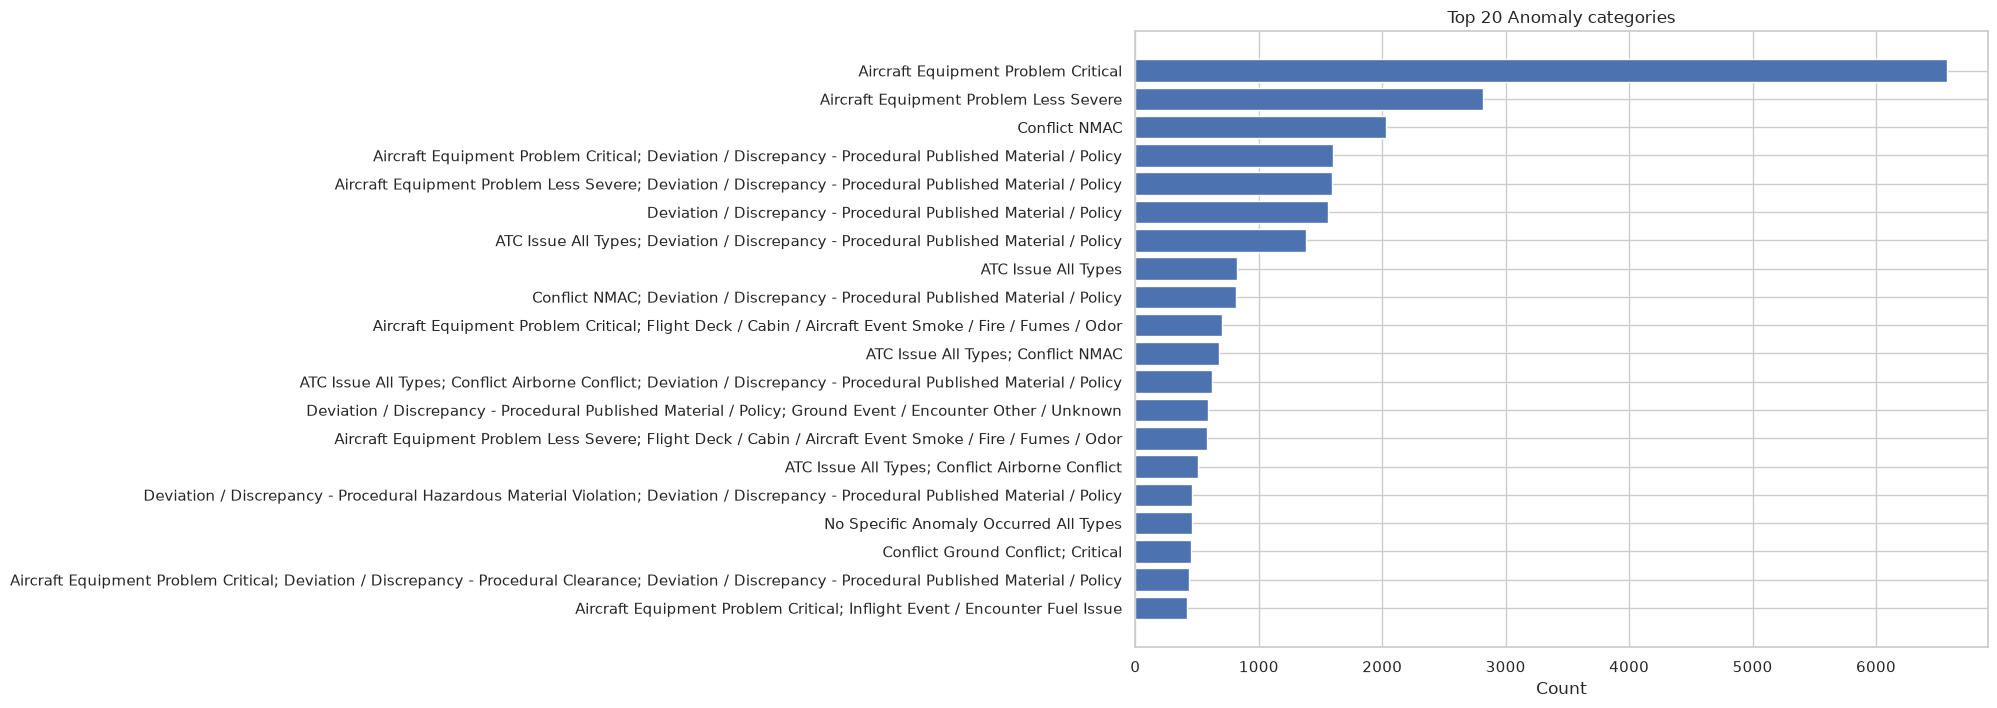

Saved: production/output/eda/top_anomalies.png


Anomaly,count
str,u32
"""Aircraft Equipment Problem Cri…",6577
"""Aircraft Equipment Problem Les…",2816
"""Conflict NMAC""",2030
"""Aircraft Equipment Problem Cri…",1602
"""Aircraft Equipment Problem Les…",1596
"""Deviation / Discrepancy - Proc…",1559
"""ATC Issue All Types; Deviation…",1381
"""ATC Issue All Types""",822
"""Conflict NMAC; Deviation / Dis…",819


In [5]:
# Top anomaly/event types over the full window
anomaly_col = "Anomaly"
anom = (
    qa.with_columns(pl.col(anomaly_col).cast(pl.Utf8).str.strip_chars().alias(anomaly_col))
      .filter(pl.col(anomaly_col) != "")
      .group_by(anomaly_col)
      .len(name="count")
      .sort("count", descending=True)
      .head(20)
)

anom_pd = anom.to_pandas().sort_values("count")
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(anom_pd[anomaly_col], anom_pd["count"])
ax.set_title("Top 20 Anomaly categories")
ax.set_xlabel("Count")
fig.tight_layout()
fig.savefig(OUT_DIR / "top_anomalies.png", dpi=140)
plt.show()

print("Saved:", OUT_DIR / "top_anomalies.png")
anom.head(10)

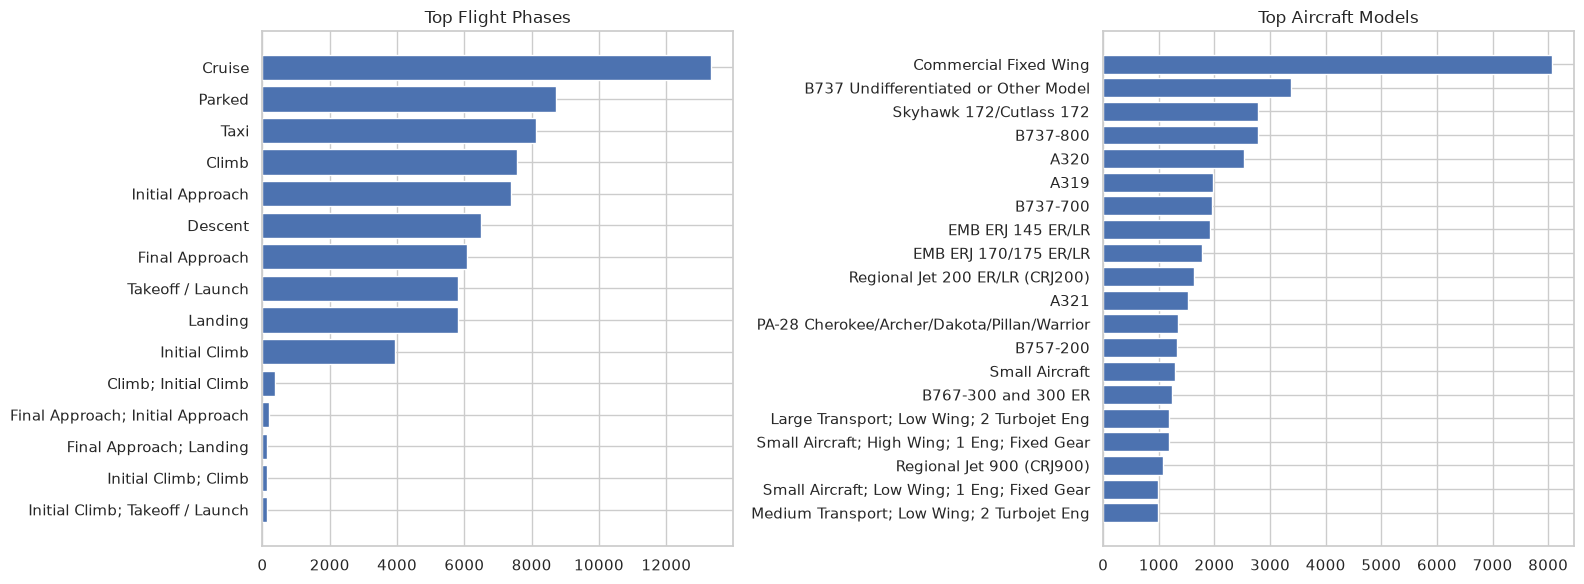

Saved: production/output/eda/phase_model_concentration.png


In [6]:
# Flight phase and aircraft model concentration checks
phase_col = "Aircraft 1 | Flight Phase"
model_col = "Aircraft 1 | Make Model Name"

phase = (
    qa.with_columns(pl.col(phase_col).cast(pl.Utf8).str.strip_chars().alias(phase_col))
      .filter(pl.col(phase_col) != "")
      .group_by(phase_col)
      .len(name="count")
      .sort("count", descending=True)
      .head(15)
)

models = (
    qa.with_columns(pl.col(model_col).cast(pl.Utf8).str.strip_chars().alias(model_col))
      .filter(pl.col(model_col) != "")
      .group_by(model_col)
      .len(name="count")
      .sort("count", descending=True)
      .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
phase_pd = phase.to_pandas().sort_values("count")
axes[0].barh(phase_pd[phase_col], phase_pd["count"])
axes[0].set_title("Top Flight Phases")

models_pd = models.to_pandas().sort_values("count")
axes[1].barh(models_pd[model_col], models_pd["count"])
axes[1].set_title("Top Aircraft Models")

fig.tight_layout()
fig.savefig(OUT_DIR / "phase_model_concentration.png", dpi=140)
plt.show()

print("Saved:", OUT_DIR / "phase_model_concentration.png")

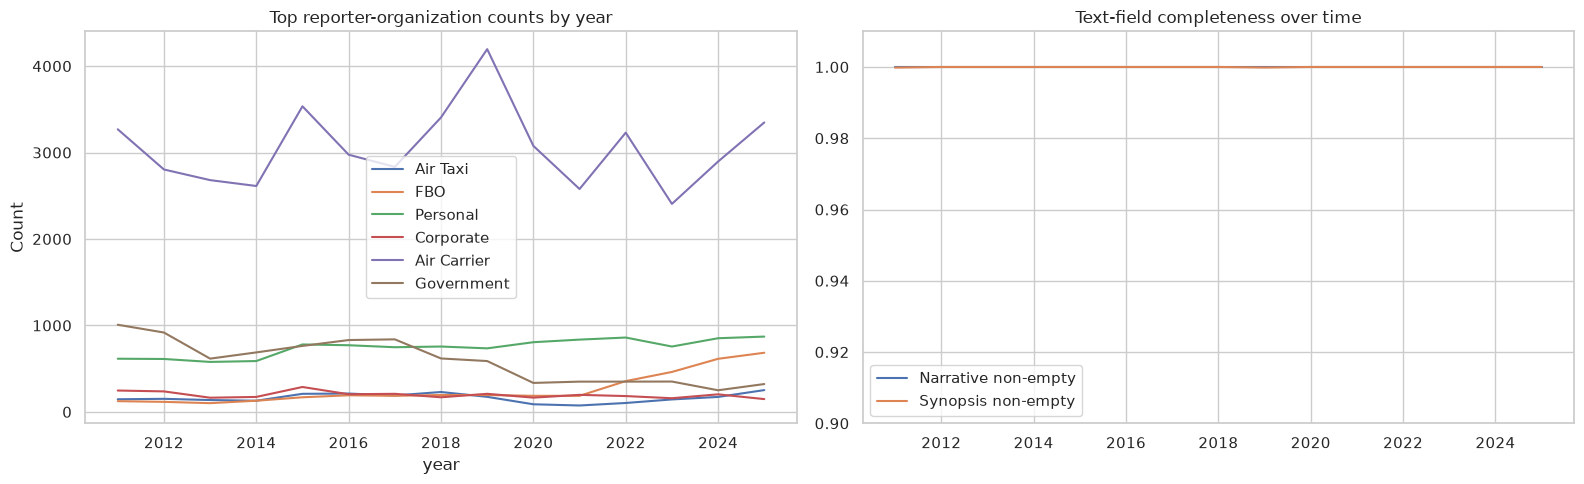

Saved: production/output/eda/reporting_bias_proxies.png


In [7]:
# Reporting-bias proxy checks:
# 1) reporter-organization mix over time
# 2) narrative/synopsis completeness stability
org_col = "Person 1 | Reporter Organization"
narr_col = "Report 1 | Narrative"
syn_col = "Synopsis"

org_year = (
    qa.with_columns(pl.col(org_col).cast(pl.Utf8).str.strip_chars().alias(org_col))
      .filter(pl.col(org_col) != "")
      .group_by(["year", org_col])
      .len(name="count")
)

top_orgs = (
    org_year.group_by(org_col)
            .agg(pl.sum("count").alias("total"))
            .sort("total", descending=True)
            .head(6)
            .select(org_col)
            .to_series()
            .to_list()
)

org_pivot = (
    org_year.filter(pl.col(org_col).is_in(top_orgs))
            .pivot(on=org_col, index="year", values="count", aggregate_function="sum")
            .sort("year")
)

quality = (
    qa.group_by("year").agg([
        (pl.col(narr_col).cast(pl.Utf8).str.strip_chars().str.len_chars() > 0).mean().alias("narrative_nonempty_rate"),
        (pl.col(syn_col).cast(pl.Utf8).str.strip_chars().str.len_chars() > 0).mean().alias("synopsis_nonempty_rate"),
    ]).sort("year")
)

org_pd = org_pivot.to_pandas().set_index("year")
quality_pd = quality.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
org_pd.plot(ax=axes[0])
axes[0].set_title("Top reporter-organization counts by year")
axes[0].set_ylabel("Count")

axes[1].plot(quality_pd["year"], quality_pd["narrative_nonempty_rate"], label="Narrative non-empty")
axes[1].plot(quality_pd["year"], quality_pd["synopsis_nonempty_rate"], label="Synopsis non-empty")
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title("Text-field completeness over time")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT_DIR / "reporting_bias_proxies.png", dpi=140)
plt.show()

print("Saved:", OUT_DIR / "reporting_bias_proxies.png")

In [8]:
# Volatility diagnostics: monthly z-score spikes
monthly_z = monthly.with_columns([
    ((pl.col("reports") - pl.col("reports").mean()) / pl.col("reports").std()).alias("z"),
]).sort("z", descending=True)

spikes = monthly_z.head(10)
spikes.write_csv(OUT_DIR / "monthly_spikes_top10.csv")
print("Saved:", OUT_DIR / "monthly_spikes_top10.csv")
spikes

Saved: production/output/eda/monthly_spikes_top10.csv


ym,reports,ma12,z
str,u32,f64,f64
"""201909""",687,526.666667,2.91881
"""201910""",685,538.416667,2.894974
"""201911""",657,549.75,2.561267
"""201507""",633,451.916667,2.275233
"""201907""",630,500.333333,2.239478
"""202007""",617,470.416667,2.084543
"""201908""",616,512.75,2.072625
"""201812""",604,471.666667,1.929607
"""201111""",591,468.272727,1.774672


In [9]:
# QA summary artifact for downstream phases
summary = {
    "rows_raw": int(df.height),
    "rows_qa_window": int(qa.height),
    "unique_acn_qa_window": int(qa.select(pl.col("ACN").n_unique()).item()),
    "date_min": qa.select(pl.min("ym")).item(),
    "date_max": qa.select(pl.max("ym")).item(),
    "top_anomaly_1": anom.row(0)[0] if anom.height > 0 else None,
    "top_anomaly_1_count": int(anom.row(0)[1]) if anom.height > 0 else None,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_DIR / "qa_summary.csv", index=False)
print(summary_df.T)
print("Saved:", OUT_DIR / "qa_summary.csv")

                                                        0
rows_raw                                            80047
rows_qa_window                                      79577
unique_acn_qa_window                                79577
date_min                                           201101
date_max                                           202512
top_anomaly_1         Aircraft Equipment Problem Critical
top_anomaly_1_count                                  6577
Saved: production/output/eda/qa_summary.csv
